In [1]:
import gymnasium as gym

import rclpy
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold
from stable_baselines3.common.vec_env import DummyVecEnv

# ==========================================
# Step 1: 创建环境 (强烈建议使用 VecEnv 包装)
# ==========================================
# 即使你只用单进程，也建议用 DummyVecEnv 包装。
# 这不仅是 SB3 架构的标配，更是为了后续可能无缝切换到多进程 SubprocVecEnv 做准备。
env = make_vec_env("CartPole-v1", n_envs=1)

# 创建一个专门用于测试评估的环境 (不要和训练环境混用)
eval_env = make_vec_env("CartPole-v1", n_envs=1)

# ==========================================
# Step 2: 设置回调函数 - 实战核心
# ==========================================
# 场景：当评估环境的平均奖励达到 475（CartPole的满分是500）时，停止训练并保存最优模型。
stop_callback = StopTrainingOnRewardThreshold(reward_threshold=475, verbose=1)

# EvalCallback 会在训练过程中定期用 eval_env 测试模型
eval_callback = EvalCallback(
    eval_env, 
    best_model_save_path="./ppo_cartpole_best/", # 最优模型保存路径
    log_path="./ppo_cartpole_logs/",              # 评估日志路径
    eval_freq=5000,                               # 每走 5000 步评估一次
    callback_on_new_best=stop_callback,           # 触发早停条件
    deterministic=True,                           # 评估时使用确定性策略(即输出均值，不加噪声)
    render=False                                  # 评估时不弹出画面
)

# ==========================================
# Step 3: 实例化 PPO 模型
# ==========================================
# "MlpPolicy" 是 SB3 内置的默认多层感知机网络。
model = PPO(
    policy="MlpPolicy",
    env=env,
    learning_rate=3e-4,
    n_steps=2048,         # 【对应我们手写的 RolloutBuffer 大小】每次收集 2048 步数据再更新
    batch_size=64,        # Mini-batch 的大小
    n_epochs=10,          # 【对应我们手写的 update_epochs】用这批数据反复训练 10 遍
    gamma=0.99,           # 折扣因子
    gae_lambda=0.95,      # 【对应我们手写的 lam】GAE 的 lambda 参数
    clip_range=0.2,       # 【对应我们手写的 eps_clip】PPO 截断范围
    ent_coef=0.0,         # 熵系数（CartPole离散任务一般设为0，连续任务如Pendulum建议设0.01~0.1鼓励探索）
    verbose=1             # 打印训练日志
)

# ==========================================
# Step 4: 开始训练
# ==========================================
print("开始训练...")
# 直接调用 learn，把 callback 传进去，全自动运行
model.learn(
    total_timesteps=100000, 
    callback=eval_callback,
    progress_bar=True      # 显示进度条 (需要安装 tqdm)
)

# ==========================================
# Step 5: 保存最终模型 (无论是否达到最优)
# ==========================================
model.save("ppo_cartpole_final_model")
print("训练结束，模型已保存。")

# ==========================================
# Step 6: 加载模型并测试/渲染
# ==========================================
# 注意：如果你在 Step 2 中触发了早停，其实 "./ppo_cartpole_best/best_model.zip" 是最强的
# 这里演示如何加载刚才保存的 final_model
del model  # 清空内存

model = PPO.load("ppo_cartpole_final_model")

# 测试 5 局并渲染画面
test_env = gym.make("CartPole-v1", render_mode="human")
obs, info = test_env.reset()

for episode in range(5):
    episode_reward = 0
    obs, info = test_env.reset()
    done = False
    while not done:
        # 【注意 deterministic=True】
        # 这正是我们之前讨论的：训练时内部带噪声，测试时直接输出均值动作！
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = test_env.step(action)
        episode_reward += reward
        done = terminated or truncated
    print(f"测试回合 {episode + 1}, 奖励: {episode_reward}")

test_env.close()


/home/chendawww/Software/anaconda3/envs/ros2/lib/python3.10/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Using cpu device


/home/chendawww/.local/lib/python3.10/site-packages/rich/live.py:231: UserWarning: install "ipywidgets" for Jupyter
support
  warnings.warn('install "ipywidgets" for Jupyter support')

开始训练...
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 20.6     |
|    ep_rew_mean     | 20.6     |
| time/              |          |
|    fps             | 3135     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 25.9        |
|    ep_rew_mean          | 25.9        |
| time/                   |             |
|    fps                  | 2094        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.009174008 |
|    clip_fraction        | 0.116       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.686      |
|    explained_variance   | -0.0101     |
|    learning_rate    

Eval num_timesteps=5000, episode_reward=425.80 +/- 144.43

...

Stopping training because the mean reward 498.80 is above the threshold 475

训练结束，模型已保存。


/home/chendawww/Software/anaconda3/envs/ros2/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


测试回合 1, 奖励: 500.0
测试回合 2, 奖励: 500.0
测试回合 3, 奖励: 500.0


KeyboardInterrupt: 

In [8]:
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold

# ==========================================
# Step 1: 创建环境 (改为 Pendulum-v1)
# ==========================================
env = make_vec_env("Pendulum-v1", n_envs=1)
eval_env = make_vec_env("Pendulum-v1", n_envs=1)

# ==========================================
# Step 2: 设置回调函数 (修改奖励阈值)
# ==========================================
# 【重要修改】Pendulum 的奖励是负数！
# 当平均奖励大于 -200 时（意味着摆杆已经能基本保持在顶部，甚至开始转圈了），我们认为它达标了。
# 你可以把 -200 调高（比如 -100）来要求它转得更完美，但训练时间会变长。
stop_callback = StopTrainingOnRewardThreshold(reward_threshold=-150, verbose=1)

eval_callback = EvalCallback(
    eval_env, 
    best_model_save_path="./ppo_pendulum_best/", 
    log_path="./ppo_pendulum_logs/",              
    eval_freq=5000,                               
    callback_on_new_best=stop_callback,           
    deterministic=True,                           
    render=False                                  
)

# ==========================================
# Step 3: 实例化 PPO 模型 (修改探索参数)
# ==========================================
# model = PPO(
#     policy="MlpPolicy", # MlpPolicy 会自动识别连续空间并输出高斯分布
#     env=env,
#     learning_rate=3e-4,
#     n_steps=2048,         
#     batch_size=64,        
#     n_epochs=10,          
#     gamma=0.99,           
#     gae_lambda=0.95,      
#     clip_range=0.2,       
#     # 【重要修改】开启熵奖励！连续任务强烈建议开启，否则它可能只学会让杆子停在下面不动（这比乱动奖励高）
#     ent_coef=0.05,         
#     verbose=1             
# )

model = PPO(
    policy="MlpPolicy",
    env=env,
    learning_rate=1e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,            # ⬅️ 大幅降低！从 0.1 降到 0.01，减少随机性
    policy_kwargs=dict(
        net_arch=[dict(pi=[64, 64], vf=[64, 64])]  # ⬅️ 回到默认大小，够用了
    ),
    verbose=1
)


# ==========================================
# Step 4: 开始训练
# ==========================================
print("开始训练 Pendulum...")
# Pendulum 相对难一点，如果 -200 的阈值没触发，这里 100000 步可能不够，可以适当加大
model.learn(
    total_timesteps=200000, 
    callback=eval_callback,
    progress_bar=True      
)

model.save("ppo_pendulum_final_model")
print("训练结束，模型已保存。")

# ==========================================
# Step 6: 加载模型并测试/渲染
# ==========================================
del model 

# 加载最优模型 (如果早停触发了的话，这个比 final 强)
try:
    model = PPO.load("./ppo_pendulum_best/best_model")
    print("加载了最优模型 (best_model)")
except:
    model = PPO.load("ppo_pendulum_final_model")
    print("未找到最优模型，加载了最终模型")

# 渲染测试
test_env = gym.make("Pendulum-v1", render_mode="human")
obs, info = test_env.reset()

for episode in range(5):
    episode_reward = 0
    obs, info = test_env.reset()
    done = False
    while not done:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = test_env.step(action)
        episode_reward += reward
        # 【关键点】Pendulum 没有 terminated，只有 200 步后的 truncated
        done = terminated or truncated 
    # 打印的奖励会是负数，越接近 0 越好
    print(f"测试回合 {episode + 1}, 奖励: {episode_reward:.2f}")

test_env.close()


Using cpu device
开始训练 Pendulum...
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 200       |
|    ep_rew_mean     | -1.18e+03 |
| time/              |           |
|    fps             | 3307      |
|    iterations      | 1         |
|    time_elapsed    | 0         |
|    total_timesteps | 2048      |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | -1.17e+03    |
| time/                   |              |
|    fps                  | 2190         |
|    iterations           | 2            |
|    time_elapsed         | 1            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0032853466 |
|    clip_fraction        | 0.0122       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.42        |
|    explained

Eval num_timesteps=5000, episode_reward=-1329.92 +/- 298.84

Episode length: 200.00 +/- 0.00

------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 200          |
|    mean_reward          | -1.33e+03    |
| time/                   |              |
|    total_timesteps      | 5000         |
| train/                  |              |
|    approx_kl            | 0.0007221984 |
|    clip_fraction        | 0            |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.42        |
|    explained_variance   | 0.0575       |
|    learning_rate        | 0.0001       |
|    loss                 | 4.42e+03     |
|    n_updates            | 20           |
|    policy_gradient_loss | -0.00035     |
|    std                  | 0.995        |
|    value_loss           | 8.69e+03     |
------------------------------------------


New best mean reward!

...

------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 200          |
|    mean_reward          | -1.05e+03    |
| time/                   |              |
|    total_timesteps      | 195000       |
| train/                  |              |
|    approx_kl            | 0.0033541708 |
|    clip_fraction        | 0.0165       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.44        |
|    explained_variance   | 5.96e-08     |
|    learning_rate        | 0.0001       |
|    loss                 | 2.26e+03     |
|    n_updates            | 950          |
|    policy_gradient_loss | -0.00237     |
|    std                  | 1.02         |
|    value_loss           | 4.12e+03     |
------------------------------------------
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 200       |
|    ep_rew_mean     | -1.09e+03 |
| time/              |           |
|    fps

Eval num_timesteps=200000, episode_reward=-1187.80 +/- 149.59

Episode length: 200.00 +/- 0.00

------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 200          |
|    mean_reward          | -1.19e+03    |
| time/                   |              |
|    total_timesteps      | 200000       |
| train/                  |              |
|    approx_kl            | 0.0032693471 |
|    clip_fraction        | 0.0132       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.43        |
|    explained_variance   | 0            |
|    learning_rate        | 0.0001       |
|    loss                 | 1.71e+03     |
|    n_updates            | 970          |
|    policy_gradient_loss | -0.0023      |
|    std                  | 1.01         |
|    value_loss           | 3.28e+03     |
------------------------------------------
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 200       |
|    ep_rew_mean     | -1.09e+03 |
| time/              |           |
|    fps

训练结束，模型已保存。
加载了最优模型 (best_model)
测试回合 1, 奖励: -1342.23
测试回合 2, 奖励: -763.03
测试回合 3, 奖励: -903.31
测试回合 4, 奖励: -885.15
测试回合 5, 奖励: -894.81


In [9]:
import gymnasium as gym
from stable_baselines3 import SAC # 1. 改这里：把 PPO 换成 SAC
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback

# ==========================================
# Step 1: 创建环境 (不变)
# ==========================================
env = make_vec_env("Pendulum-v1", n_envs=1)
eval_env = make_vec_env("Pendulum-v1", n_envs=1)

# ==========================================
# Step 2: 设置回调函数 (去掉早停，只保留评估)
# ==========================================
eval_callback = EvalCallback(
    eval_env, 
    best_model_save_path="./sac_pendulum_best/", 
    log_path="./sac_pendulum_logs/",              
    eval_freq=5000,                               
    # 删掉了 callback_on_new_best=stop_callback
    deterministic=True,                           
    render=False                                  
)

# ==========================================
# Step 3: 实例化 SAC 模型 (核心改动)
# ==========================================
model = SAC(
    policy="MlpPolicy",
    env=env,
    learning_rate=3e-4,
    buffer_size=50000,      # 【SAC特有】经验回放池大小，5万够用了
    learning_starts=1000,   # 【SAC特有】刚开始先随机玩1000步，攒点数据再学
    batch_size=256,         # SAC 默认 256，比 PPO 的 64 大，跑得更稳
    tau=0.005,              # 【SAC特有】软更新系数 (别动它，默认就好)
    gamma=0.99,
    # ent_coef='auto',      # 【SAC的灵魂】默认就是 auto，它会自动调节探索的"熵"，完美解决你之前"甩上去停不下来"的毛病！
    verbose=1
)

# ==========================================
# Step 4: 开始训练
# ==========================================
print("开始训练 Pendulum (SAC算法)...")
# SAC 收敛比 PPO 快很多，通常 3~5万步就能看到完美的结果，给10万步绰绰有余
model.learn(
    total_timesteps=100000, 
    callback=eval_callback,
    progress_bar=True      
)

model.save("sac_pendulum_final_model")
print("训练结束，模型已保存。")

# ==========================================
# Step 5: 测试渲染
# ==========================================
del model 
# 直接加载最优模型
model = SAC.load("./sac_pendulum_best/best_model")

test_env = gym.make("Pendulum-v1", render_mode="human")

for episode in range(5):
    episode_reward = 0
    obs, info = test_env.reset()
    done = False
    while not done:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = test_env.step(action)
        episode_reward += reward
        done = terminated or truncated
    print(f"测试回合 {episode + 1}, 奖励: {episode_reward:.2f}")

test_env.close()


Using cpu device
开始训练 Pendulum (SAC算法)...
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 200       |
|    ep_rew_mean     | -1.26e+03 |
| time/              |           |
|    episodes        | 4         |
|    fps             | 6138      |
|    time_elapsed    | 0         |
|    total_timesteps | 800       |
----------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -1.3e+03 |
| time/              |          |
|    episodes        | 8        |
|    fps             | 239      |
|    time_elapsed    | 6        |
|    total_timesteps | 1600     |
| train/             |          |
|    actor_loss      | 19.2     |
|    critic_loss     | 0.345    |
|    ent_coef        | 0.837    |
|    ent_coef_loss   | -0.289   |
|    learning_rate   | 0.0003   |
|    n_updates       | 599      |
---------------------------------
------------------------------

Eval num_timesteps=5000, episode_reward=-99.43 +/- 49.52

Episode length: 200.00 +/- 0.00

---------------------------------
| eval/              |          |
|    mean_ep_length  | 200      |
|    mean_reward     | -99.4    |
| time/              |          |
|    total_timesteps | 5000     |
| train/             |          |
|    actor_loss      | 81.8     |
|    critic_loss     | 0.653    |
|    ent_coef        | 0.392    |
|    ent_coef_loss   | -0.413   |
|    learning_rate   | 0.0003   |
|    n_updates       | 3999     |
---------------------------------


New best mean reward!

...

---------------------------------
| eval/              |          |
|    mean_ep_length  | 200      |
|    mean_reward     | -142     |
| time/              |          |
|    total_timesteps | 95000    |
| train/             |          |
|    actor_loss      | 15.4     |
|    critic_loss     | 0.208    |
|    ent_coef        | 0.0393   |
|    ent_coef_loss   | 0.59     |
|    learning_rate   | 0.0003   |
|    n_updates       | 93999    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -163     |
| time/              |          |
|    episodes        | 476      |
|    fps             | 94       |
|    time_elapsed    | 1011     |
|    total_timesteps | 95200    |
| train/             |          |
|    actor_loss      | 15       |
|    critic_loss     | 0.124    |
|    ent_coef        | 0.039    |
|    ent_coef_loss   | 0.0512   |
|    learning_rate   | 0.0003   |
|    n_updates

Eval num_timesteps=100000, episode_reward=-168.32 +/- 95.95

Episode length: 200.00 +/- 0.00

---------------------------------
| eval/              |          |
|    mean_ep_length  | 200      |
|    mean_reward     | -168     |
| time/              |          |
|    total_timesteps | 100000   |
| train/             |          |
|    actor_loss      | 16.8     |
|    critic_loss     | 0.395    |
|    ent_coef        | 0.0318   |
|    ent_coef_loss   | 0.591    |
|    learning_rate   | 0.0003   |
|    n_updates       | 98999    |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -160     |
| time/              |          |
|    episodes        | 500      |
|    fps             | 93       |
|    time_elapsed    | 1064     |
|    total_timesteps | 100000   |
---------------------------------


训练结束，模型已保存。
测试回合 1, 奖励: -1.03
测试回合 2, 奖励: -0.45
测试回合 3, 奖励: -124.62
测试回合 4, 奖励: -126.72
测试回合 5, 奖励: -217.77


In [14]:
del model 
# 直接加载最优模型
model = SAC.load("./sac_pendulum_best/best_model")

test_env = gym.make("Pendulum-v1", render_mode="human")

for episode in range(5):
    episode_reward = 0
    obs, info = test_env.reset()
    done = False
    while not done:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = test_env.step(action)
        episode_reward += reward
        done = terminated or truncated
    print(f"测试回合 {episode + 1}, 奖励: {episode_reward:.2f}")

test_env.close()


测试回合 1, 奖励: -121.01
测试回合 2, 奖励: -119.06
测试回合 3, 奖励: -120.80
测试回合 4, 奖励: -0.17
测试回合 5, 奖励: -127.52


In [16]:
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback
import torch.nn as nn

# ==========================================
# Step 1: 创建环境
# ==========================================
env = make_vec_env("Pendulum-v1", n_envs=1)
eval_env = make_vec_env("Pendulum-v1", n_envs=1)

# ==========================================
# Step 2: 评估回调
# ==========================================
eval_callback = EvalCallback(
    eval_env, 
    best_model_save_path="./ppo_pendulum_best/", 
    log_path="./ppo_pendulum_logs/",              
    eval_freq=10000,                               
    deterministic=True,                           
    render=False                                  
)

# ==========================================
# Step 3: 稳定版 重装 PPO 配置
# ==========================================
model = PPO(
    policy="MlpPolicy",
    env=env,
    
    learning_rate=3e-4,      
    n_steps=2048,
    batch_size=256,          # 保持 256，大网络配大 batch 更稳
    n_epochs=10,
    
    # --- 核心纠偏 ---
    clip_range=0.2,          # ⬅️ 收回 0.4！大网络必须用默认的 0.2 守住底线
    ent_coef=0.01,           # ⬅️ 回归合理值，提供基础探索
    
    # --- 网络结构 (依然是对标 SAC 的 256x256) ---
    policy_kwargs=dict(
        net_arch=dict(pi=[256, 256], vf=[256, 256]),
        # ⬅️ 灵魂补丁：正交初始化
        # 大网络极容易在一开始就死掉（梯度消失/爆炸），正交初始化能让 20万个参数起步时保持完美的对称和活力
        activation_fn=nn.Tanh, 
        ortho_init=True      
    ),
    
    gamma=0.99,
    gae_lambda=0.95,
    verbose=1
)

# ==========================================
# Step 4: 开始训练 (PPO 需要的时间长一点)
# ==========================================
print("开始训练 Pendulum (稳定版 重装 PPO)...")
# 大网络 PPO 收敛慢，给足 50万步
model.learn(
    total_timesteps=500000, 
    callback=eval_callback,
    progress_bar=True      
)

model.save("ppo_pendulum_sota_model")
print("训练结束，模型已保存。")

# ==========================================
# Step 5: 测试渲染
# ==========================================
del model 
model = PPO.load("./ppo_pendulum_best/best_model")

test_env = gym.make("Pendulum-v1", render_mode="human")
for episode in range(5):
    episode_reward = 0
    obs, info = test_env.reset()
    done = False
    while not done:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = test_env.step(action)
        episode_reward += reward
        done = terminated or truncated
    print(f"PPO 测试回合 {episode + 1}, 奖励: {episode_reward:.2f}")
test_env.close()


Using cpu device
开始训练 Pendulum (稳定版 重装 PPO)...
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 200       |
|    ep_rew_mean     | -1.23e+03 |
| time/              |           |
|    fps             | 2265      |
|    iterations      | 1         |
|    time_elapsed    | 0         |
|    total_timesteps | 2048      |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 200          |
|    ep_rew_mean          | -1.23e+03    |
| time/                   |              |
|    fps                  | 1998         |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0017099506 |
|    clip_fraction        | 0.00742      |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.42        |
|

Eval num_timesteps=10000, episode_reward=-1131.45 +/- 107.70

Episode length: 200.00 +/- 0.00

------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 200          |
|    mean_reward          | -1.13e+03    |
| time/                   |              |
|    total_timesteps      | 10000        |
| train/                  |              |
|    approx_kl            | 0.0025275415 |
|    clip_fraction        | 0.00625      |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.41        |
|    explained_variance   | 0.328        |
|    learning_rate        | 0.0003       |
|    loss                 | 3.3e+03      |
|    n_updates            | 40           |
|    policy_gradient_loss | -0.00124     |
|    std                  | 0.994        |
|    value_loss           | 7.73e+03     |
------------------------------------------


New best mean reward!

...

Episode length: 200.00 +/- 0.00

------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 200          |
|    mean_reward          | -98          |
| time/                   |              |
|    total_timesteps      | 500000       |
| train/                  |              |
|    approx_kl            | 0.0055624526 |
|    clip_fraction        | 0.0407       |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.939       |
|    explained_variance   | 0.996        |
|    learning_rate        | 0.0003       |
|    loss                 | 0.763        |
|    n_updates            | 2440         |
|    policy_gradient_loss | -0.000826    |
|    std                  | 0.618        |
|    value_loss           | 2.77         |
------------------------------------------


New best mean reward!

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -165     |
| time/              |          |
|    fps             | 1712     |
|    iterations      | 245      |
|    time_elapsed    | 293      |
|    total_timesteps | 501760   |
---------------------------------


训练结束，模型已保存。
PPO 测试回合 1, 奖励: -254.21
PPO 测试回合 2, 奖励: -123.74
PPO 测试回合 3, 奖励: -238.82
PPO 测试回合 4, 奖励: -2.79
PPO 测试回合 5, 奖励: -125.06


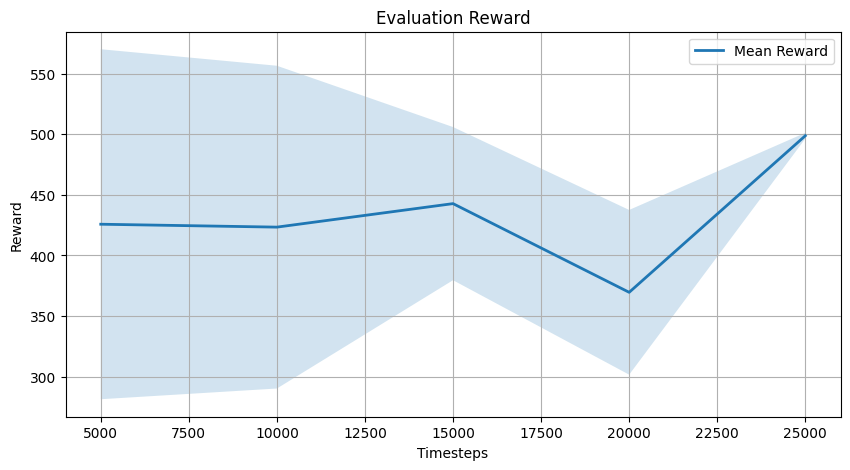

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# =======================
npz_path = "/home/chendawww/workspace/rl-navibot/src/decision/rl_agent/rl_agent/rl/ppo_pendulum_logs/evaluations.npz"
# npz_path = "/home/chendawww/workspace/rl-navibot/src/decision/rl_agent/rl_agent/rl/sac_pendulum_logs/evaluations.npz"
npz_path = "/home/chendawww/workspace/rl-navibot/src/decision/rl_agent/rl_agent/rl/ppo_cartpole_logs/evaluations.npz"
# =======================

data = np.load(npz_path)

timesteps = data["timesteps"]
results = data["results"]  # 形状：(评估次数, 每次评估局数)
ep_lengths = data["ep_lengths"]

# 自己计算均值和标准差（旧版SB3必须这样）
mean_reward = np.mean(results, axis=1)
std_reward = np.std(results, axis=1)

# 绘图
plt.figure(figsize=(10, 5))
plt.plot(timesteps, mean_reward, linewidth=2, label="Mean Reward")
plt.fill_between(timesteps, mean_reward - std_reward, mean_reward + std_reward, alpha=0.2)
plt.xlabel("Timesteps")
plt.ylabel("Reward")
plt.title("Evaluation Reward")
plt.grid(True)
plt.legend()
plt.show()

In [17]:
del model 
model = PPO.load("./ppo_pendulum_best/best_model")

test_env = gym.make("Pendulum-v1", render_mode="human")
for episode in range(5):
    episode_reward = 0
    obs, info = test_env.reset()
    done = False
    while not done:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = test_env.step(action)
        episode_reward += reward
        done = terminated or truncated
    print(f"PPO 测试回合 {episode + 1}, 奖励: {episode_reward:.2f}")
test_env.close()

PPO 测试回合 1, 奖励: -0.68
PPO 测试回合 2, 奖励: -244.82
PPO 测试回合 3, 奖励: -127.12
PPO 测试回合 4, 奖励: -369.61
PPO 测试回合 5, 奖励: -122.24


In [ ]:
"""
TurtleBot3 Waffle 导航 Gymnasium 环境 (ROS2 原生版)

依赖: rclpy, sensor_msgs, nav_msgs, geometry_msgs
观测空间 (37 维):
    [0:24]  LiDAR        (降采样, [0,1])
    [24:27] IMU 线加速度
    [27:30] IMU 角速度
    [30:32] IMU 姿态     [Roll, Pitch]
    [32]    目标相对角度 (归一化 [-1,1]) -> dyaw
    [33]    目标距离     (归一化 [0,1]) -> distance
    [34]    里程计线速度
    [35]    里程计角速度
    [36]    上一步动作线速度
"""

import math
import time
import threading
import logging
from typing import Optional, Dict, Any, Tuple

import numpy as np
import gymnasium as gym
from gymnasium import spaces

# ROS2 相关导入
import rclpy
from rclpy.node import Node
from rclpy.qos import QoSProfile, ReliabilityPolicy, HistoryPolicy
from sensor_msgs.msg import LaserScan, Imu
from nav_msgs.msg import Odometry
from geometry_msgs.msg import Twist, PoseStamped, TransformStamped
from tf2_ros import TransformException
from tf2_ros.buffer import Buffer
from tf2_ros.transform_listener import TransformListener

logger = logging.getLogger(__name__)

class TurtleBot3HouseEnv(gym.Env, Node):
    """
    直接继承 rclpy.Node，去除外部接口依赖。
    """

    metadata = {"render_modes": []}

    # 默认 House 地图安全区域 (XML 坐标)
    DEFAULT_SAFE_ZONES = [
        {"cx":  0.0, "cy":  0.0, "r": 1.2},
        {"cx":  1.8, "cy":  1.0, "r": 0.7},
        {"cx": -1.8, "cy":  1.0, "r": 0.7},
        {"cx":  1.8, "cy": -1.0, "r": 0.7},
        {"cx": -1.8, "cy": -1.0, "r": 0.7},
        {"cx":  3.0, "cy":  0.0, "r": 0.6},
        {"cx": -3.0, "cy":  0.0, "r": 0.6},
    ]

    def __init__(self, config: Optional[Dict[str, Any]] = None):
        # 初始化 Gym 环境
        gym.Env.__init__(self)
        
        cfg = config or {}

        # --- 参数配置 ---
        self.max_laser_range    = cfg.get("max_laser_range", 3.5)
        self.laser_num_beams    = cfg.get("laser_num_beams", 24)
        self.max_lin_vel        = cfg.get("max_lin_vel", 0.22)
        self.max_ang_vel        = cfg.get("max_ang_vel", 1.5)
        self.goal_threshold     = cfg.get("goal_threshold", 0.30)
        self.collision_threshold = cfg.get("collision_threshold", 0.20)
        self.max_episode_steps  = cfg.get("max_episode_steps", 500)
        self.step_duration      = cfg.get("step_duration", 0.1)
        self.max_goal_dist      = cfg.get("max_goal_dist", 5.0)
        self.min_goal_distance  = cfg.get("min_goal_distance", 1.5)
        
        # 物理极限
        self.max_lin_acc        = cfg.get("max_lin_acc", 2.0)
        self.max_ang_vel_imu    = cfg.get("max_ang_vel_imu", 3.0)

        # 安全区域
        self.safe_zones = cfg.get("safe_zones", self.DEFAULT_SAFE_ZONES)

        # --- 奖励权重 ---
        self.r_goal             = cfg.get("reward_goal", 200.0)
        self.r_collision        = cfg.get("reward_collision", -200.0)
        self.r_dist_scale       = cfg.get("reward_dist_scale", 10.0)
        self.r_time             = cfg.get("reward_time", -0.05)
        self.r_heading          = cfg.get("reward_heading", 2.0)
        self.r_smoothness       = cfg.get("reward_smoothness", -0.1)
        self.r_safety           = cfg.get("reward_safety", -2.0)

        # --- 初始化 ROS2 Node ---
        # 注意：如果外部已经 init 了 rclpy，这里不需要再次 init
        # 但通常在 Gym 环境内部初始化 Node 比较方便管理生命周期
        if not rclpy.ok():
            rclpy.init()
        
        Node.__init__(self, 'turtlebot3_gym_env')
        
        # --- 数据缓存与锁 (线程安全) ---
        self._lock = threading.Lock()
        self._latest_scan: Optional[LaserScan] = None
        self._latest_imu: Optional[Imu] = None
        self._latest_odom: Optional[Odometry] = None

        # --- 订阅者 (使用 Best Effort 适配 Gazebo) ---
        qos_profile = QoSProfile(
            reliability=ReliabilityPolicy.BEST_EFFORT,
            history=HistoryPolicy.KEEP_LAST,
            depth=1
        )

        self.scan_sub = self.create_subscription(
            LaserScan, '/scan', self._scan_cb, qos_profile)
        self.imu_sub = self.create_subscription(
            Imu, '/imu', self._imu_cb, qos_profile)
        # 使用你指定的 filtered odom
        self.odom_sub = self.create_subscription(
            Odometry, '/odometry/filtered', self._odom_cb, qos_profile)

        # --- 发布者 ---
        self.vel_pub = self.create_publisher(Twist, '/cmd_vel', 10)
        self.goal_pub = self.create_publisher(PoseStamped, '/goal_pose', 10)

        # --- ROS2 Spin 线程 ---
        # 必须在一个独立线程中 spin，否则 step 函数会阻塞
        self._spin_thread = threading.Thread(target=self._spin, daemon=True)
        self._spin_thread.start()

        # --- 空间定义 ---
        self._obs_size = self.laser_num_beams + 3 + 3 + 2 + 1 + 1 + 2 + 1
        self.observation_space = spaces.Box(
            low=-1.0, high=1.0, shape=(self._obs_size,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=np.array([-self.max_lin_vel, -self.max_ang_vel], dtype=np.float32),
            high=np.array([ self.max_lin_vel,  self.max_ang_vel], dtype=np.float32),
            dtype=np.float32,
        )

        # --- 内部状态 ---
        self.goal_x = 0.0
        self.goal_y = 0.0
        self.prev_dist = 0.0
        self.episode_step = 0
        self.last_action = np.zeros(2, dtype=np.float32)
        
        logger.info("TurtleBot3HouseEnv initialized with direct ROS2 interface.")

    # ==================== ROS2 回调与工具 ====================

    def _spin(self):
        """后台线程运行 ros2 spin"""
        rclpy.spin(self)

    def _scan_cb(self, msg: LaserScan):
        with self._lock:
            self._latest_scan = msg

    def _imu_cb(self, msg: Imu):
        with self._lock:
            self._latest_imu = msg

    def _odom_cb(self, msg: Odometry):
        with self._lock:
            self._latest_odom = msg

    def _get_odom_data(self) -> Optional[Dict]:
        with self._lock:
            if self._latest_odom is None: return None
            p = self._latest_odom.pose.pose.position
            o = self._latest_odom.pose.pose.orientation
            t = self._latest_odom.twist.twist
            
            # 四元数转欧拉角
            siny_cosp = 2 * (o.w * o.z + o.x * o.y)
            cosy_cosp = 1 - 2 * (o.y * o.y + o.z * o.z)
            yaw = math.atan2(siny_cosp, cosy_cosp)

            return {
                "x": p.x, "y": p.y, "yaw": yaw,
                "vx": t.linear.x, "vy": t.linear.y, "vz": t.angular.z
            }

    def _get_imu_data(self) -> Optional[Dict]:
        with self._lock:
            if self._latest_imu is None: return None
            a = self._latest_imu.linear_acceleration
            g = self._latest_imu.angular_velocity
            o = self._latest_imu.orientation
            
            # 计算 Roll, Pitch
            sinr_cosp = 2 * (o.w * o.x + o.y * o.z)
            cosr_cosp = 1 - 2 * (o.x * o.x + o.y * o.y)
            roll = math.atan2(sinr_cosp, cosr_cosp)
            
            sinp = 2 * (o.w * o.y - o.z * o.x)
            pitch = math.asin(np.clip(sinp, -1.0, 1.0))

            return {
                "acc": [a.x, a.y, a.z],
                "gyro": [g.x, g.y, g.z],
                "rpy": [roll, pitch] # Yaw 我们通常更相信 Odom 的
            }

    def _get_laser_data(self) -> np.ndarray:
        with self._lock:
            if self._latest_scan is None:
                return np.ones(self.laser_num_beams, dtype=np.float32)
            
            ranges = np.array(self._latest_scan.ranges)
            # 处理无效值
            ranges = np.nan_to_num(ranges, nan=self.max_laser_range, 
                                   posinf=self.max_laser_range, neginf=0.0)
            ranges = np.clip(ranges, 0, self.max_laser_range)
            
            # 降采样
            n = len(ranges)
            step = max(1, n // self.laser_num_beams)
            # 取每段最小值
            sampled = np.array([np.min(ranges[i:i+step]) for i in range(0, n, step)])
            
            # 如果采样点数多于需求，截断；少于则填充
            if len(sampled) > self.laser_num_beams:
                sampled = sampled[:self.laser_num_beams]
            elif len(sampled) < self.laser_num_beams:
                sampled = np.pad(sampled, (0, self.laser_num_beams - len(sampled)), 
                                 'constant', constant_values=self.max_laser_range)
            
            return sampled / self.max_laser_range

    def send_velocity(self, lin_x, ang_z):
        msg = Twist()
        msg.linear.x = float(lin_x)
        msg.angular.z = float(ang_z)
        self.vel_pub.publish(msg)

    # ==================== Gym 接口 ====================

    def reset(self, *, seed: Optional[int] = None, options: Optional[Dict] = None) -> Tuple[np.ndarray, Dict]:
        gym.Env.reset(self, seed=seed)
        
        # 1. 停止运动
        self.send_velocity(0.0, 0.0)
        self.last_action = np.zeros(2, dtype=np.float32)
        self.episode_step = 0
        
        # 2. 随机目标点
        start = self._sample_safe_position()
        goal = self._sample_safe_position()
        attempts = 0
        while self._euclidean(start, goal) < self.min_goal_distance and attempts < 20:
            goal = self._sample_safe_position()
            attempts += 1
            
        self.goal_x, self.goal_y = goal

        # 3. 传送机器人 (这里需要 Gazebo 服务，假设调用外部函数或直接发布 initialpose)
        # 由于直接在环境里调用服务比较重，且容易阻塞，这里建议直接发布到 /initialpose
        # 但 Gazebo 通常需要调用 /gazebo/set_entity_state
        # 为了简化演示，这里假设机器人位置由外部脚本或已有的 Reset 机制处理
        # 如果你的环境没有自动重置机制，你需要在这里调用 Gazebo 服务
        # 这里仅打印提示
        # self.call_gazebo_reset_service(start[0], start[1], self.np_random.uniform(-math.pi, math.pi))
        
        # 等待传感器数据刷新
        time.sleep(0.2) 

        # 4. 发布 Goal Marker (可视化)
        p = PoseStamped()
        p.header.frame_id = "map"
        p.pose.position.x = self.goal_x
        p.pose.position.y = self.goal_y
        p.pose.position.z = 0.0
        p.pose.orientation.w = 1.0
        self.goal_pub.publish(p)

        # 5. 获取初始观测
        obs = self._get_obs()
        odom = self._get_odom_data()
        self.prev_dist = self._goal_dist(odom) if odom else self.max_goal_dist
        
        return obs, {"start": start, "goal": goal}

    def step(self, action: np.ndarray) -> Tuple[np.ndarray, float, bool, bool, Dict]:
        action = np.clip(action, self.action_space.low, self.action_space.high)
        
        # 1. 执行动作
        self.send_velocity(action[0], action[1])
        time.sleep(self.step_duration)
        
        # 2. 获取数据
        obs = self._get_obs()
        odom = self._get_odom_data()
        imu  = self._get_imu_data()
        
        if odom is None:
            return obs, -1.0, False, True, {"error": "odom unavailable"}

        curr_dist = self._goal_dist(odom)
        
        # 3. 终止判定
        goal_reached = curr_dist < self.goal_threshold
        collision    = self._check_collision()
        
        # 4. 奖励
        reward = self._compute_reward(
            curr_dist=curr_dist, prev_dist=self.prev_dist,
            goal_reached=goal_reached, collision=collision,
            action=action, odom=odom, imu=imu
        )
        
        # 5. 更新状态
        self.prev_dist = curr_dist
        self.last_action = action
        self.episode_step += 1
        
        terminated = goal_reached or collision
        truncated  = self.episode_step >= self.max_episode_steps
        
        if terminated or truncated:
            self.send_velocity(0.0, 0.0)
            
        return obs, float(reward), terminated, truncated, {}

    def close(self):
        self.send_velocity(0.0, 0.0)
        # 销毁节点
        self.destroy_node()
        # 注意：通常不在这里 shutdown rclpy，因为外部可能还在用

    # ==================== 内部逻辑 ====================

    def _sample_safe_position(self) -> Tuple[float, float]:
        zone = self.safe_zones[self.np_random.integers(len(self.safe_zones))]
        angle = self.np_random.uniform(0, 2 * math.pi)
        r = self.np_random.uniform(0, zone["r"])
        return (zone["cx"] + r * math.cos(angle), zone["cy"] + r * math.sin(angle))

    @staticmethod
    def _euclidean(a, b):
        return math.hypot(a[0] - b[0], a[1] - b[1])

    def _goal_dist(self, odom: Dict) -> float:
        return math.hypot(self.goal_x - odom["x"], self.goal_y - odom["y"])

    def _check_collision(self) -> bool:
        # 直接读最新的 scan 缓存
        with self._lock:
            if self._latest_scan is None: return False
            ranges = np.array(self._latest_scan.ranges)
            ranges = np.nan_to_num(ranges, nan=self.max_laser_range, posinf=self.max_laser_range)
            return float(np.min(ranges)) < self.collision_threshold

    def _min_laser(self) -> float:
        with self._lock:
            if self._latest_scan is None: return self.max_laser_range
            ranges = np.array(self._latest_scan.ranges)
            ranges = np.nan_to_num(ranges, nan=self.max_laser_range, posinf=self.max_laser_range)
            return float(np.min(ranges))

    def _get_obs(self) -> np.ndarray:
        # 1. LiDAR
        laser_norm = self._get_laser_data() # 已经归一化

        # 2. IMU & Odom
        odom = self._get_odom_data()
        imu  = self._get_imu_data()

        imu_acc = np.zeros(3, dtype=np.float32)
        imu_gyro = np.zeros(3, dtype=np.float32)
        imu_rp = np.zeros(2, dtype=np.float32)
        goal_angle, goal_dist = 0.0, 1.0
        odom_vel = np.zeros(2, dtype=np.float32)

        if imu is not None:
            imu_acc = np.clip(np.array(imu['acc']) / self.max_lin_acc, -1.0, 1.0)
            imu_gyro = np.clip(np.array(imu['gyro']) / self.max_ang_vel_imu, -1.0, 1.0)
            imu_rp = np.clip(np.array(imu['rpy'][:2]) / (math.pi/4), -1.0, 1.0) # Roll, Pitch

        if odom is not None:
            # 计算相对位姿 (dx, dy, dyaw)
            # 这里的 dx, dy 是世界坐标系下的差值
            dx = self.goal_x - odom['x']
            dy = self.goal_y - odom['y']
            
            # 转换到机器人坐标系
            yaw = odom['yaw']
            # 机器人坐标系下的目标位置
            local_x = dx * math.cos(yaw) + dy * math.sin(yaw)
            local_y = -dx * math.sin(yaw) + dy * math.cos(yaw)
            
            # 相对角度
            goal_angle = math.atan2(local_y, local_x) / math.pi # 归一化到 [-1, 1]
            # 相对距离
            goal_dist = min(math.hypot(dx, dy) / self.max_goal_dist, 1.0)
            
            # 里程计速度
            odom_vel = np.clip(
                np.array([odom['vx'], odom['vz']]) / np.array([self.max_lin_vel, self.max_ang_vel]), 
                -1.0, 1.0
            )

        last_act_norm = np.clip(self.last_action[0] / self.max_lin_vel, -1.0, 1.0)

        obs = np.concatenate([
            laser_norm,          # 24
            imu_acc,             # 3
            imu_gyro,            # 3
            imu_rp,              # 2
            [goal_angle],        # 1 (相对偏角)
            [goal_dist],         # 1 (相对距离)
            odom_vel,            # 2
            [last_act_norm]      # 1
        ]).astype(np.float32)
        
        return obs

    def _compute_reward(self, curr_dist, prev_dist, goal_reached, collision, action, odom, imu):
        reward = 0.0
        
        if goal_reached: return self.r_goal
        if collision:    return self.r_collision

        # 1. 距离变化奖励
        dist_delta = prev_dist - curr_dist
        reward += dist_delta * self.r_dist_scale

        # 2. 朝向奖励
        # 利用 obs 中计算好的逻辑，或者重算
        yaw = odom['yaw']
        target_angle = math.atan2(self.goal_y - odom['y'], self.goal_x - odom['x'])
        yaw_error = math.atan2(math.sin(target_angle - yaw), math.cos(target_angle - yaw))
        heading_factor = math.cos(yaw_error) # 1.0 (正对) -> -1.0 (背对)
        
        if abs(odom['vx']) > 0.01:
            reward += heading_factor * self.r_heading

        # 3. 安全惩罚
        min_dist = self._min_laser()
        if min_dist < 0.4:
            reward += self.r_safety * ((0.4 - min_dist) / 0.4)**2

        # 4. 平滑性惩罚
        if imu is not None:
            # 惩罚剧烈的 z 轴角速度 (震荡)
            if abs(imu['gyro'][2]) > 1.0:
                reward += self.r_smoothness * abs(imu['gyro'][2])

        # 5. 时间惩罚
        reward += self.r_time
        
        return reward

